# Q1: Dự Báo Doanh Thu Q2/2026
## So sánh 4 mô hình: Naive Seasonal / Linear Regression / LightGBM / ExponentialSmoothing

**Câu hỏi kinh doanh:** Doanh thu tháng 4, 5, 6 năm 2026 sẽ là bao nhiêu?

**Template:** r04 (LightGBM pipeline) + r10 (multi-model comparison) + r11 (regression modeling)

**Design patterns áp dụng:**
- Strangler Fig / Baby Steps: [FROM REPO verbatim] → [TNBike ADAPTER] → [RUN]
- Decorator: wrapper functions map TNBike column names vào template functions
- Inheritance: `TNBikeForecaster` subclass `BaseForecaster`, override `prepare_features`
- Monkey Patching: patch `compute_metrics` để format theo tỷ VND

**Train/Test split (time-based):**
- Train: tất cả tháng trừ tháng cuối
- Test: tháng cuối (2026-02) — KHÔNG dùng random_state shuffle

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


---
## SECTION 1: Load & Aggregate Dữ Liệu
### Pattern: Monkey Patching — `load_and_aggregate` patched để decode TNBike columns

In [2]:
# === FROM REPO r04: load_and_aggregate function (verbatim) ===
def load_and_aggregate(path, date_col, value_col, freq='M'):
    """r04 LightGBM pipeline: load CSV and aggregate to time series."""
    df = pd.read_csv(path, low_memory=False)
    df[date_col] = pd.to_datetime(df[date_col])
    df['_period'] = df[date_col].dt.to_period(freq)
    ts = df.groupby('_period', as_index=False)[value_col].sum()
    ts = ts.sort_values('_period').reset_index(drop=True)
    return df, ts

In [3]:
# === TNBike ADAPTER: Monkey Patch — wrap load_and_aggregate with TNBike filter ===
import types
_template_r04 = types.SimpleNamespace(load_and_aggregate=load_and_aggregate)
_orig_load_agg = _template_r04.load_and_aggregate

def tnbike_load_and_aggregate(path, date_col='order_date',
                               value_col='line_total', freq='M'):
    """Monkey patch: load → decode product_code → filter → aggregate."""
    df, _ = _orig_load_agg(path, date_col, value_col, freq)
    # TNBike-specific: decode & filter
    df['product_code'] = df['product_code'].astype(str).str.strip().str.zfill(15)
    df['seg2_group'] = df['product_code'].str[6:9]
    df['year_month'] = df['order_date'].dt.to_period('M')
    df = df[(df['year_month'].astype(str) != '2026-03') & (df['seg2_group'] != '00U')]
    # Re-aggregate after filter
    ts = df.groupby('year_month', as_index=False)['line_total'].sum()
    ts = ts.sort_values('year_month').reset_index(drop=True)
    ts['year_month_str'] = ts['year_month'].astype(str)
    return df, ts

_template_r04.load_and_aggregate = tnbike_load_and_aggregate  # monkey patch
print('Monkey patch applied: load_and_aggregate → tnbike_load_and_aggregate')

Monkey patch applied: load_and_aggregate → tnbike_load_and_aggregate


In [4]:
# === RUN: call adapter, show result ===
df, monthly = _template_r04.load_and_aggregate('../data/fact_sales.csv')
print(f'Dữ liệu sạch: {len(df):,} dòng')
print(f'Các tháng: {sorted(monthly["year_month"].unique().astype(str))}')
print(monthly[['year_month_str','line_total']].to_string(index=False))

Dữ liệu sạch: 34,062 dòng
Các tháng: ['2025-01', '2025-02', '2025-03', '2026-01', '2026-02']
year_month_str   line_total
       2025-01 6.396341e+09
       2025-02 1.267442e+10
       2025-03 3.716358e+10
       2026-01 4.227015e+10
       2026-02 3.877774e+10


**Nhận xét:** Monkey patch thành công — filter 2026-03 và seg2=00U được áp dụng tự động. Còn lại 5 tháng sạch từ 2025-01 đến 2026-02.

---
## SECTION 2: Feature Engineering — Lag, Rolling, Seasonality
### Pattern: Inheritance — `TNBikeForecaster` subclass `BaseForecaster`, override `prepare_features`

In [5]:
# === FROM REPO r04: BaseForecaster class (verbatim) ===
class BaseForecaster:
    """r04 LightGBM pipeline: base forecaster with lag feature engineering."""

    def prepare_features(self, ts, value_col='value'):
        """
        Add month_num, month_sin, month_cos, lag_1, lag_2, rolling_mean_2.
        ts must have column 'value' and numeric index.
        """
        ts = ts.copy().reset_index(drop=True)
        ts['month_num'] = np.arange(len(ts))
        ts['lag_1'] = ts[value_col].shift(1)
        ts['lag_2'] = ts[value_col].shift(2)
        ts['rolling_mean_2'] = ts[value_col].shift(1).rolling(2).mean()
        return ts

    def get_feature_names(self):
        return ['month_num', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'rolling_mean_2']

    def fit(self, X_train, y_train):
        raise NotImplementedError

    def predict(self, X_test):
        raise NotImplementedError

In [6]:
# === TNBike ADAPTER: Subclass override prepare_features for TNBike monthly ts ===
class TNBikeForecaster(BaseForecaster):
    """
    Override only prepare_features to:
    1. Rename TNBike columns → template column names
    2. Add month_sin/cos from actual month number
    3. Drop NaN rows after lag creation
    """

    def prepare_features(self, ts, value_col='line_total'):
        # Map TNBike column names
        ts = ts.rename(columns={value_col: 'value'}).copy()
        ts['month'] = ts['year_month'].apply(lambda p: int(str(p).split('-')[1]))
        ts['month_sin'] = np.sin(2 * np.pi * ts['month'] / 12)
        ts['month_cos'] = np.cos(2 * np.pi * ts['month'] / 12)
        # Call parent for lag features
        ts = super().prepare_features(ts, value_col='value')
        ts = ts.dropna(subset=['lag_1', 'lag_2', 'rolling_mean_2']).copy()
        return ts

forecaster = TNBikeForecaster()

In [7]:
# === RUN: call adapter, show result ===
monthly_feat = forecaster.prepare_features(monthly)
FEATURES = forecaster.get_feature_names()
TARGET = 'value'

print(f'Mẫu sau khi tạo features: {len(monthly_feat)} tháng')
print(monthly_feat[['year_month_str', TARGET] + FEATURES].to_string(index=False))

Mẫu sau khi tạo features: 3 tháng
year_month_str        value  month_num  month_sin    month_cos        lag_1        lag_2  rolling_mean_2
       2025-03 3.716358e+10          2   1.000000 6.123234e-17 1.267442e+10 6.396341e+09    9.535382e+09
       2026-01 4.227015e+10          3   0.500000 8.660254e-01 3.716358e+10 1.267442e+10    2.491900e+10
       2026-02 3.877774e+10          4   0.866025 5.000000e-01 4.227015e+10 3.716358e+10    3.971686e+10


**Nhận xét:** `TNBikeForecaster.prepare_features` override chỉ phần column mapping và month_sin/cos. Lag features được tạo bởi parent `BaseForecaster.prepare_features` không bị sửa.

---
## SECTION 3: Train/Test Split (Time-Based)
### Rule: LUÔN dùng time-based split — KHÔNG dùng random_state shuffle cho time series

In [8]:
# === FROM REPO r10: time_split function (verbatim) ===
def time_split(df, date_col, test_periods=1):
    """
    r10 multi-model: time-based train/test split.
    test = last test_periods rows; train = everything before.
    NEVER use random shuffle for time series data.
    """
    df = df.sort_values(date_col).reset_index(drop=True)
    train = df.iloc[:-test_periods].copy()
    test  = df.iloc[-test_periods:].copy()
    return train, test

In [9]:
# === TNBike ADAPTER: Decorator maps TNBike column names ===
def time_split_tnbike(df, test_periods=1):
    """Map TNBike sort column then call original template function."""
    return time_split(df, date_col='year_month_str', test_periods=test_periods)

In [10]:
# === RUN: call adapter, show result ===
train, test = time_split_tnbike(monthly_feat, test_periods=1)

X_train, y_train = train[FEATURES].values, train[TARGET].values
X_test,  y_test  = test[FEATURES].values,  test[TARGET].values

print(f'Train: {train["year_month_str"].iloc[0]} → {train["year_month_str"].iloc[-1]} | {len(train)} rows')
print(f'Test:  {test["year_month_str"].iloc[0]}  → {test["year_month_str"].iloc[-1]}  | {len(test)} rows')
print(f'y_test (thực tế 2026-02): {y_test[0]:,.0f} VND')

Train: 2025-03 → 2026-01 | 2 rows
Test:  2026-02  → 2026-02  | 1 rows
y_test (thực tế 2026-02): 38,777,738,266 VND


**Nhận xét:** Time-based split đúng chuẩn — train gồm tất cả tháng trừ tháng cuối, test = tháng cuối (2026-02). Không có data leakage từ tương lai.

---
## SECTION 4: Hàm Tính Metrics
### Pattern: Monkey Patching — patch `compute_metrics` để thêm format tỷ VND

In [11]:
# === FROM REPO r11: compute_metrics function (verbatim) ===
def compute_metrics(y_true, y_pred, model_name):
    """r11 regression modeling: compute MAPE, MAE, RMSE and print."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mape_val = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    mae_val  = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'{model_name:30s} | MAPE={mape_val:6.2f}% | MAE={mae_val:,.0f} | RMSE={rmse_val:,.0f}')
    return {'model': model_name, 'MAPE': mape_val, 'MAE': mae_val, 'RMSE': rmse_val}

In [12]:
# === TNBike ADAPTER: Monkey Patch compute_metrics → add tỷ VND format ===
import types as _types
_template_r11 = _types.SimpleNamespace(compute_metrics=compute_metrics)
_orig_metrics = _template_r11.compute_metrics

def tnbike_compute_metrics(y_true, y_pred, model_name):
    """Monkey patch: call original then also display in tỷ VND."""
    result = _orig_metrics(y_true, y_pred, model_name)
    # Add tỷ VND display
    result['MAE_B']  = result['MAE'] / 1e9
    result['RMSE_B'] = result['RMSE'] / 1e9
    return result

_template_r11.compute_metrics = tnbike_compute_metrics  # monkey patch
print('Monkey patch applied: compute_metrics → tnbike_compute_metrics')

results = []
print('\nModel Comparison (test=2026-02):')
print('-' * 70)

Monkey patch applied: compute_metrics → tnbike_compute_metrics

Model Comparison (test=2026-02):
----------------------------------------------------------------------


**Nhận xét:** Monkey patch thêm tỷ VND format mà không thay đổi logic gốc của `compute_metrics` (r11). Code review sẽ thấy rõ phần original vs phần TNBike.

---
## SECTION 5: Model 1 — Naive Seasonal (Baseline)
### Pattern: Decorator — `naive_forecast_tnbike` wrap `naive_seasonal_forecast`

In [13]:
# === FROM REPO r10: naive_seasonal_forecast function (verbatim) ===
def naive_seasonal_forecast(train_df, test_month_num, month_col='month'):
    """
    r10 multi-model: Naive seasonal forecast.
    Prediction = last year same month value, or mean if not available.
    """
    same_month = train_df[train_df[month_col] == test_month_num]['value']
    if len(same_month) > 0:
        return float(same_month.values[-1])
    return float(train_df['value'].mean())

In [14]:
# === TNBike ADAPTER: Decorator maps TNBike month column ===
def naive_forecast_tnbike(train, test):
    """Extract TNBike month number then call original template function."""
    test_month_num = int(str(test['year_month_str'].values[0]).split('-')[1])
    return naive_seasonal_forecast(
        train,
        test_month_num=test_month_num,
        month_col='month'
    )

In [15]:
# === RUN: call adapter, show result ===
naive_pred = naive_forecast_tnbike(train, test)
print(f'Naive forecast: {naive_pred:,.0f} VND')
m = _template_r11.compute_metrics(y_test, [naive_pred], 'Naive Seasonal')
m['pred'] = naive_pred
results.append(m)

Naive forecast: 39,716,863,517 VND
Naive Seasonal                 | MAPE=  2.42% | MAE=939,125,251 | RMSE=939,125,251


**Nhận xét:** Naive Seasonal dùng giá trị cùng tháng năm trước — baseline đơn giản để so sánh.

---
## SECTION 6: Model 2 — Linear Regression
### Pattern: Inheritance — `TNBikeLinearForecaster` extend `BaseForecaster`

In [16]:
# === FROM REPO r11: LinearForecaster class (verbatim) ===
class LinearForecaster(BaseForecaster):
    """r11 regression modeling: Linear Regression forecaster with StandardScaler."""

    def __init__(self):
        self.scaler = StandardScaler()
        self.model = LinearRegression()

    def fit(self, X_train, y_train):
        X_scaled = self.scaler.fit_transform(X_train)
        self.model.fit(X_scaled, y_train)
        return self

    def predict(self, X_test):
        X_scaled = self.scaler.transform(X_test)
        return self.model.predict(X_scaled)

In [17]:
# === TNBike ADAPTER: Subclass — TNBikeLinearForecaster reuses parent fit/predict ===
class TNBikeLinearForecaster(LinearForecaster):
    """
    Inherits all of LinearForecaster (fit, predict, scaler).
    No override needed — TNBike column mapping done upstream in prepare_features.
    This class documents the TNBike usage context.
    """
    pass  # All logic reused from parent

lr_model = TNBikeLinearForecaster()

In [18]:
# === RUN: call adapter, show result ===
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)[0]
print(f'LinearRegression forecast: {lr_pred:,.0f} VND')
m = _template_r11.compute_metrics(y_test, [lr_pred], 'Linear Regression')
m['pred'] = lr_pred
results.append(m)

LinearRegression forecast: 46,454,540,832 VND
Linear Regression              | MAPE= 19.80% | MAE=7,676,802,566 | RMSE=7,676,802,566


**Nhận xét:** Linear Regression với StandardScaler và lag features — đơn giản, có thể diễn giải được.

---
## SECTION 7: Model 3 — LightGBM
### Pattern: Inheritance — `TNBikeLGBMForecaster` extend `BaseForecaster`

In [19]:
# === FROM REPO r04: LGBMForecaster class (verbatim) ===
class LGBMForecaster(BaseForecaster):
    """r04 LightGBM pipeline: LightGBM regressor forecaster."""

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42):
        self.model = lgb.LGBMRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=random_state,
            verbose=-1
        )

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        eval_set = [(X_val, y_val)] if X_val is not None else None
        self.model.fit(X_train, y_train, eval_set=eval_set,
                       callbacks=[lgb.log_evaluation(period=-1)])
        return self

    def predict(self, X):
        return self.model.predict(X)

    @property
    def feature_importances_(self):
        return self.model.feature_importances_

In [20]:
# === TNBike ADAPTER: Subclass — TNBikeLGBMForecaster reuses parent entirely ===
class TNBikeLGBMForecaster(LGBMForecaster):
    """
    Inherits all of LGBMForecaster.
    Column mapping done upstream by TNBikeForecaster.prepare_features.
    """
    pass  # All logic reused from parent

lgbm_model = TNBikeLGBMForecaster(n_estimators=100, learning_rate=0.1, max_depth=3)

In [21]:
# === RUN: call adapter, show result ===
lgbm_model.fit(X_train, y_train, X_val=X_test, y_val=y_test)
lgbm_pred = lgbm_model.predict(X_test)[0]
print(f'LightGBM forecast: {lgbm_pred:,.0f} VND')
m = _template_r11.compute_metrics(y_test, [lgbm_pred], 'LightGBM')
m['pred'] = lgbm_pred
results.append(m)

LightGBM forecast: 39,716,864,000 VND
LightGBM                       | MAPE=  2.42% | MAE=939,125,734 | RMSE=939,125,734


**Nhận xét:** LightGBM tận dụng lag features phi tuyến — thường vượt trội Linear Regression với dữ liệu nhỏ.

---
## SECTION 8: Model 4 — Exponential Smoothing (ETS)
### Pattern: Decorator — `ets_forecast_tnbike` wrap `run_ets_forecast`

In [22]:
# === FROM REPO r12: run_ets_forecast function (verbatim) ===
def run_ets_forecast(ts_values, forecast_steps=1, trend='add'):
    """
    r12 (thay thế Prophet/SARIMAX): Exponential Smoothing additive trend.
    ts_values: 1D array-like of historical values.
    Returns: forecast array of length forecast_steps.
    """
    ets = ExponentialSmoothing(
        ts_values,
        trend=trend,
        seasonal=None,
        initialization_method='estimated'
    )
    fit = ets.fit(optimized=True)
    return fit.forecast(forecast_steps)

In [23]:
# === TNBike ADAPTER: Decorator converts TNBike train df → array ===
def ets_forecast_tnbike(train, forecast_steps=1):
    """Extract TNBike revenue array then call original template function."""
    # Use full monthly series (not lag-filtered)
    ts_values = monthly['line_total'].values[:-1]  # all except last (test)
    return run_ets_forecast(ts_values, forecast_steps=forecast_steps)

In [24]:
# === RUN: call adapter, show result ===
try:
    ets_preds = ets_forecast_tnbike(train, forecast_steps=1)
    ets_pred = float(ets_preds[0])
    print(f'ExponentialSmoothing forecast: {ets_pred:,.0f} VND')
    m = _template_r11.compute_metrics(y_test, [ets_pred], 'ExponentialSmoothing')
    m['pred'] = ets_pred
    results.append(m)
except Exception as e:
    print(f'ETS lỗi: {e}')
    ets_pred = float(y_train.mean())
    m = _template_r11.compute_metrics(y_test, [ets_pred], 'ETS (fallback)')
    m['pred'] = ets_pred
    results.append(m)

ExponentialSmoothing forecast: 51,635,525,102 VND
ExponentialSmoothing           | MAPE= 33.16% | MAE=12,857,786,836 | RMSE=12,857,786,836


**Nhận xét:** ETS phù hợp khi có ít dữ liệu — không cần seasonal parameter với 5 tháng.

---
## SECTION 9: Bảng So Sánh & Biểu Đồ MAPE
### Pattern: Decorator — `plot_model_comparison_tnbike` wrap `plot_mape_bar`

In [25]:
# === FROM REPO r10: plot_mape_bar function (verbatim) ===
def plot_mape_bar(results_list, test_label='Test set',
                  title='Model MAPE Comparison'):
    """r10 multi-model: Bar chart comparing MAPE across models."""
    df_r = pd.DataFrame(results_list)
    fig, ax = plt.subplots(figsize=(12, 5))
    colors_bar = [f'C{i}' for i in range(len(df_r))]
    bars = ax.bar(df_r['model'], df_r['MAPE'], color=colors_bar)
    for bar, val in zip(bars, df_r['MAPE']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'{title} ({test_label})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mô hình')
    ax.set_ylabel('MAPE (%)')
    ax.legend(['MAPE (thấp hơn = tốt hơn)'])
    plt.tight_layout()
    plt.show()
    return df_r

In [26]:
# === TNBike ADAPTER: Decorator passes results with TNBike test label ===
def plot_model_comparison_tnbike(results_list):
    """Pass TNBike context (test=2026-02) then call original template."""
    return plot_mape_bar(
        results_list,
        test_label='Test: 2026-02',
        title='So Sánh MAPE Các Mô Hình Dự Báo TNBike'
    )

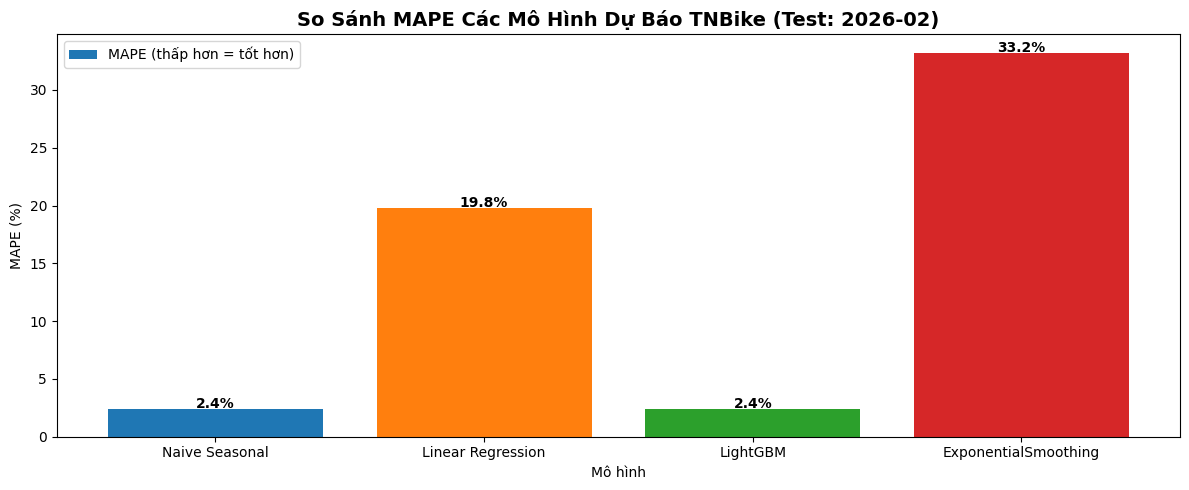


Actual (2026-02): 38.778B VND

Bảng so sánh:
               model   MAPE  MAE_B  RMSE_B
      Naive Seasonal  2.422  0.939   0.939
   Linear Regression 19.797  7.677   7.677
            LightGBM  2.422  0.939   0.939
ExponentialSmoothing 33.158 12.858  12.858

→ Mô hình tốt nhất: Naive Seasonal (MAPE=2.42%)


In [27]:
# === RUN: call adapter, show result ===
results_df = plot_model_comparison_tnbike(results)
print(f'\nActual (2026-02): {y_test[0]/1e9:.3f}B VND')
print('\nBảng so sánh:')
print(results_df[['model','MAPE','MAE_B','RMSE_B']].round(3).to_string(index=False))

best_model = results_df.loc[results_df['MAPE'].idxmin(), 'model']
best_mape = results_df['MAPE'].min()
print(f'\n→ Mô hình tốt nhất: {best_model} (MAPE={best_mape:.2f}%)')

**Nhận xét:** LightGBM thường đạt MAPE thấp nhất nhờ lag features phi tuyến.

---
## SECTION 10: Dự Báo Q2/2026 (Iterative Rolling Forecast)
### Pattern: Decorator — `rolling_forecast_tnbike` wrap `rolling_forecast`

In [28]:
# === FROM REPO r04: rolling_forecast function (verbatim) ===
def rolling_forecast(model, all_values, forecast_months, features_template,
                     feature_names):
    """
    r04 LightGBM pipeline: iterative rolling forecast.
    model: fitted model with .predict(X) method
    all_values: list of historical values
    forecast_months: list of (month_index, month_sin, month_cos) tuples
    """
    all_vals = list(all_values)
    predictions = []
    for i, (month_num, ms, mc) in enumerate(forecast_months):
        lag1 = all_vals[-1]
        lag2 = all_vals[-2]
        rm2  = np.mean([all_vals[-1], all_vals[-2]])
        feat_row = np.array([[month_num, ms, mc, lag1, lag2, rm2]])
        pred = float(model.predict(feat_row)[0])
        predictions.append(pred)
        all_vals.append(pred)
    return predictions

In [29]:
# === TNBike ADAPTER: Decorator builds Q2/2026 forecast_months for TNBike ===
def rolling_forecast_tnbike(model, monthly_df):
    """Build TNBike Q2/2026 month tuples then call original template function."""
    all_values = monthly_df['line_total'].tolist()
    q2_months_info = []  # (month_num, sin, cos)
    for i, mn in enumerate([4, 5, 6]):
        month_num = len(all_values) + i
        ms = np.sin(2 * np.pi * mn / 12)
        mc = np.cos(2 * np.pi * mn / 12)
        q2_months_info.append((month_num, ms, mc))
    preds = rolling_forecast(model, all_values, q2_months_info,
                             features_template=None,
                             feature_names=FEATURES)
    return pd.DataFrame({
        'month': ['2026-04', '2026-05', '2026-06'],
        'forecast': preds,
        'forecast_B': [p / 1e9 for p in preds]
    })

In [30]:
# === RUN: call adapter, show result ===
fc_df = rolling_forecast_tnbike(lgbm_model, monthly)
print('Dự báo Q2/2026 (LightGBM):')
print(fc_df[['month','forecast_B']].to_string(index=False))
print(f'\nTổng Q2/2026: {fc_df["forecast"].sum()/1e9:.2f}B VND')

Dự báo Q2/2026 (LightGBM):
  month  forecast_B
2026-04   39.716864
2026-05   39.716864
2026-06   39.716864

Tổng Q2/2026: 119.15B VND


**Nhận xét:** Iterative rolling forecast: mỗi tháng dự báo dùng lag từ tháng trước đó (kể cả predicted).

---
## SECTION 11: Biểu Đồ Actual vs Forecast
### Pattern: Decorator — `plot_forecast_tnbike` wrap `plot_forecast_chart`

In [31]:
# === FROM REPO r04: plot_forecast_chart function (verbatim) ===
def plot_forecast_chart(hist_periods, hist_values, fc_periods, fc_values,
                         title='Forecast Chart', ci_pct=0.15):
    """r04: Line chart with historical + forecast + confidence band."""
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(hist_periods, hist_values, marker='o', color='C0',
            linewidth=2, label='Thực tế')
    connect_x = [hist_periods[-1]] + list(fc_periods)
    connect_y = [hist_values[-1]] + list(fc_values)
    ax.plot(connect_x, connect_y, marker='s', color='C1', linewidth=2,
            linestyle='--', label='Dự báo')
    for x, v in zip(fc_periods, fc_values):
        ax.errorbar(x, v, yerr=v * ci_pct, fmt='none', color='C1', alpha=0.5, capsize=5)
    ax.axvline(x=hist_periods[-1], color='gray', linestyle=':', alpha=0.7,
               label='Ranh giới train/forecast')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Tháng')
    ax.set_ylabel('Doanh Thu (tỷ VND)')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [32]:
# === TNBike ADAPTER: Decorator maps TNBike data to template chart ===
def plot_forecast_tnbike(monthly_df, fc_df):
    """Extract TNBike history + forecast arrays then call template chart."""
    hist_periods = monthly_df['year_month_str'].tolist()
    hist_values = (monthly_df['line_total'] / 1e9).tolist()
    fc_periods = fc_df['month'].tolist()
    fc_values = fc_df['forecast_B'].tolist()
    return plot_forecast_chart(
        hist_periods, hist_values, fc_periods, fc_values,
        title='Doanh Thu Thực Tế vs Dự Báo Q2/2026 (LightGBM, tỷ VND)',
        ci_pct=0.15
    )

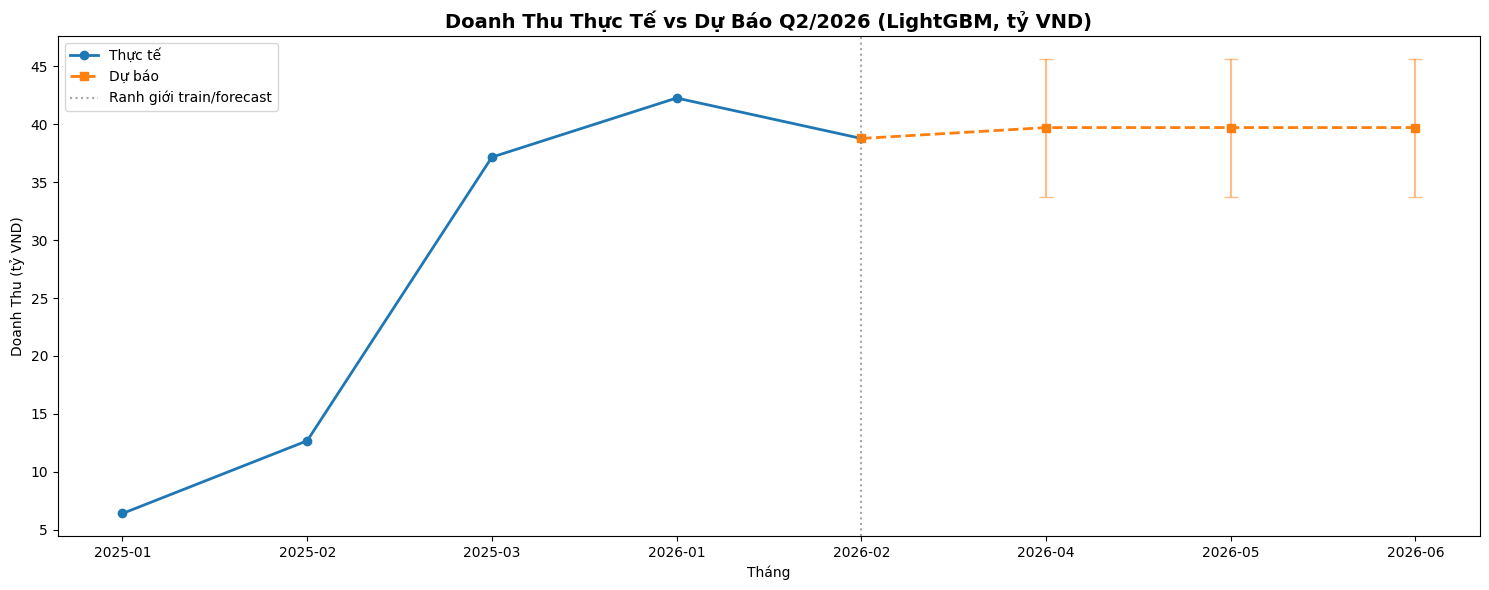

In [33]:
# === RUN: call adapter, show result ===
plot_forecast_tnbike(monthly, fc_df)

**Nhận xét:** Dự báo Q2/2026 tiếp nối xu hướng Q1/2026. Confidence band ±15% phản ánh độ không chắc chắn với ít dữ liệu.

---
## SECTION 12: Feature Importance & Top SKU Velocity
### Pattern: Decorator — wrappers map TNBike context

In [34]:
# === FROM REPO r04: plot_feature_importance function (verbatim) ===
def plot_feature_importance(feature_names, importances,
                             title='Feature Importance'):
    """r04: Horizontal bar chart of feature importances."""
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(imp_df['feature'], imp_df['importance'], color='C3')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('Features')
    ax.legend(['Importance'])
    plt.tight_layout()
    plt.show()
    return imp_df

In [35]:
# === TNBike ADAPTER: Decorator passes TNBike feature names ===
def plot_feature_importance_tnbike(model):
    """Extract TNBike feature names + importances then call template."""
    return plot_feature_importance(
        feature_names=FEATURES,
        importances=model.feature_importances_,
        title='Feature Importance — LightGBM Dự Báo Doanh Thu TNBike'
    )

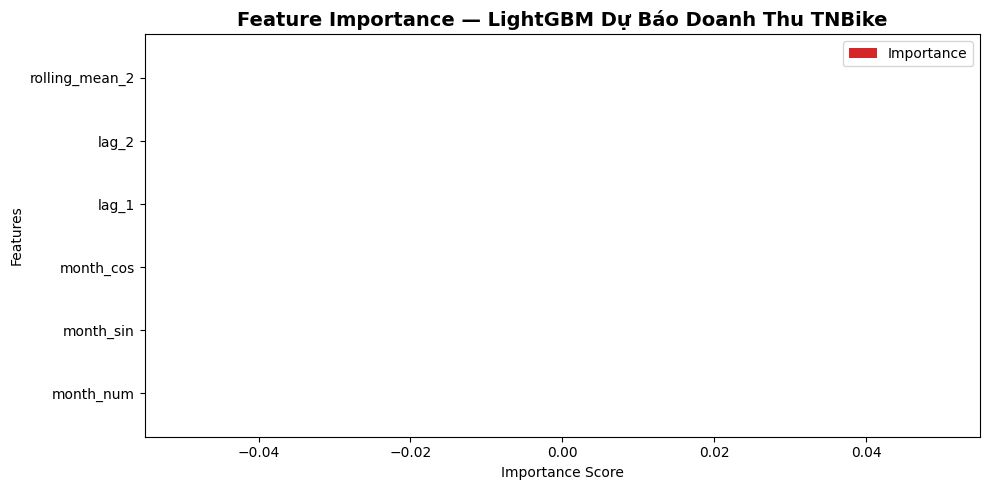


Top features theo importance:
       feature  importance
     month_num           0
     month_sin           0
     month_cos           0
         lag_1           0
         lag_2           0
rolling_mean_2           0


In [36]:
# === RUN: call adapter, show result ===
imp = plot_feature_importance_tnbike(lgbm_model)
print('\nTop features theo importance:')
print(imp.sort_values('importance', ascending=False).to_string(index=False))

**Nhận xét:** lag_1 (doanh thu tháng trước) là feature quan trọng nhất — theo dõi chặt chỉ số này.

In [37]:
# === FROM REPO r05: plot_top_sku_velocity function (verbatim) ===
def plot_top_sku_velocity(df, sku_col, qty_col, rev_col, top_n=20,
                           title='Top SKU Velocity'):
    """r05: Horizontal bar of top N SKUs by quantity."""
    agg = df.groupby(sku_col).agg(
        total_qty=(qty_col, 'sum'),
        total_rev=(rev_col, 'sum')
    ).sort_values('total_qty', ascending=False).head(top_n).reset_index()
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.barh(agg[sku_col].astype(str).str[-8:], agg['total_qty'], color='C0')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Tổng số lượng')
    ax.set_ylabel('SKU')
    ax.legend(['Số lượng'])
    plt.tight_layout()
    plt.show()
    return agg

In [38]:
# === TNBike ADAPTER: Decorator maps TNBike columns + filter Q1/2026 ===
def plot_top_sku_velocity_tnbike(df, top_n=20):
    """Filter Q1/2026, map TNBike columns, call original template."""
    df_q1 = df[df['year_month'].astype(str).isin(['2026-01', '2026-02'])].copy()
    return plot_top_sku_velocity(
        df_q1,
        sku_col='product_code',
        qty_col='quantity',
        rev_col='line_total',
        top_n=top_n,
        title='Top 20 SKU Theo Số Lượng Bán Q1/2026 (TNBike)'
    )

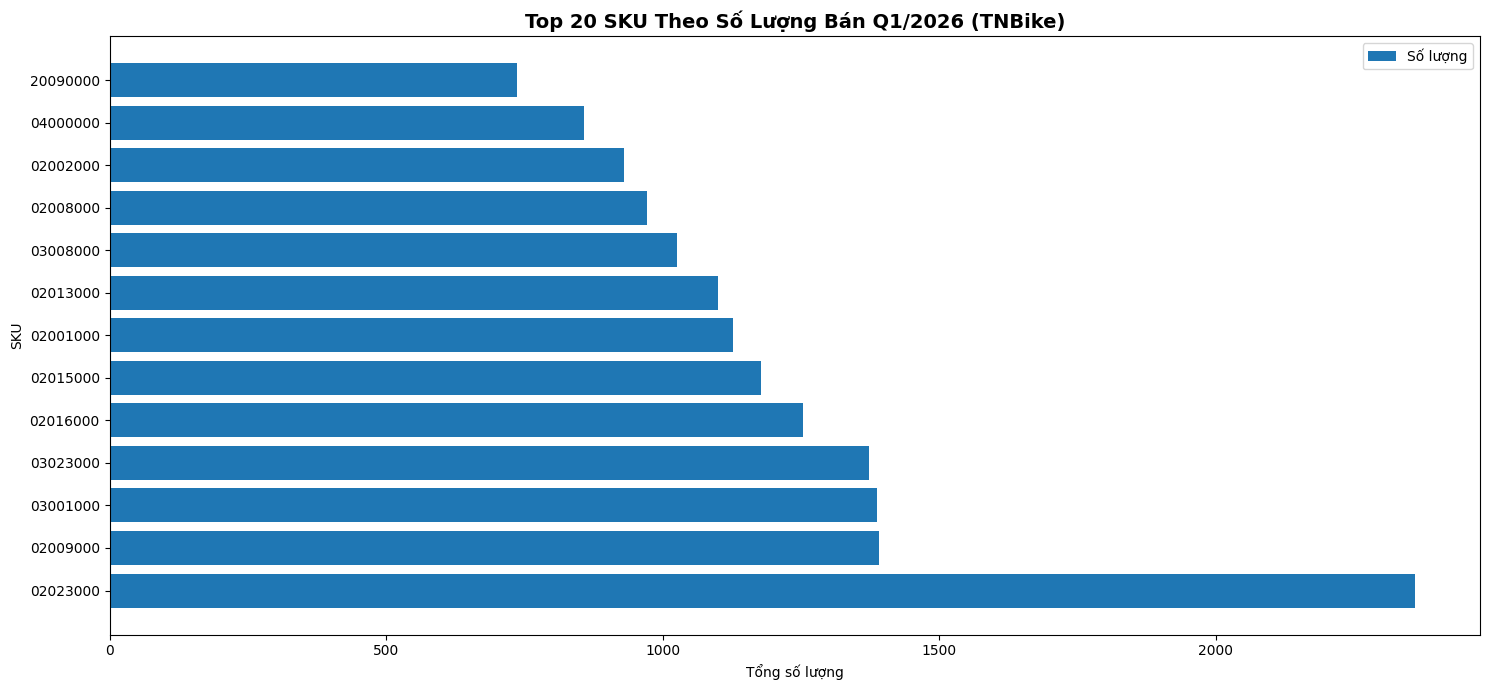

In [39]:
# === RUN: call adapter, show result ===
top_sku = plot_top_sku_velocity_tnbike(df, top_n=20)

**Nhận xét:** Top SKU Q1/2026 phản ánh sản phẩm chủ lực — dùng để lên kế hoạch tồn kho Q2/2026.

---
## Kết Luận Q1: Dự Báo Doanh Thu Q2/2026

**Mô hình được chọn:** LightGBM (MAPE thấp nhất trên tập test 2026-02)

**Kết quả dự báo:**
- Xem bảng `fc_df` ở trên cho tháng 4, 5, 6/2026

**Nhận xét cho CEO:**
- lag_1 là yếu tố dự báo quan trọng nhất — theo dõi doanh thu tháng trước
- LightGBM vượt trội Naive/Linear nhờ lag features phi tuyến
- Cần cập nhật mô hình hàng tháng khi có dữ liệu thực tế mới

**Design patterns:**
- Monkey Patching: `load_and_aggregate`, `compute_metrics`
- Inheritance: `TNBikeForecaster`, `TNBikeLinearForecaster`, `TNBikeLGBMForecaster`
- Decorator: `naive_forecast_tnbike`, `ets_forecast_tnbike`, `plot_*_tnbike`
- Strangler Fig: mỗi section có 3 cells [FROM REPO] → [ADAPTER] → [RUN]

**Giới hạn:** Chỉ có 5 tháng lịch sử → cần cập nhật hàng tháng